# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Kolkata Weather Dataset](https://www.kaggle.com/datasets/sumanbera19/kolkata-climate-and-weather-20212025-daily-data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('kolkata_weather_jan_june_2026.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,time,weather_code,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,precipitation_hours,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,sunrise,sunset,sunshine_duration,city,latitude,longitude
0,2021-06-30,65,29.9,33.4,28.0,11.6,11.6,6.0,23.7,46.1,206,2021-06-30T04:55,2021-06-30T18:25,20837.76,Kolkata,22.5726,88.3639
1,2021-07-01,63,29.8,33.4,27.8,10.5,10.5,10.0,19.1,37.1,193,2021-07-01T04:55,2021-07-01T18:25,21439.24,Kolkata,22.5726,88.3639
2,2021-07-02,63,29.2,32.2,27.8,15.9,15.9,13.0,18.7,33.8,209,2021-07-02T04:56,2021-07-02T18:25,12291.52,Kolkata,22.5726,88.3639
3,2021-07-03,63,29.2,32.9,27.3,7.6,7.6,11.0,15.5,32.0,202,2021-07-03T04:56,2021-07-03T18:25,29486.65,Kolkata,22.5726,88.3639
4,2021-07-04,63,28.6,32.1,26.9,8.0,8.0,11.0,12.0,29.5,180,2021-07-04T04:56,2021-07-04T18:25,41145.46,Kolkata,22.5726,88.3639


## last Five row

In [4]:
df.tail()

,time,weather_code,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,precipitation_hours,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,sunrise,sunset,sunshine_duration,city,latitude,longitude
1822,2026-06-26,63,29.8,32.9,27.0,6.2,6.2,5.0,9.3,27.4,166,2026-06-26T04:54,2026-06-26T18:25,44119.09,Kolkata,22.5726,88.3639
1823,2026-06-27,53,30.2,34.3,27.5,2.0,2.0,8.0,12.3,26.6,160,2026-06-27T04:54,2026-06-27T18:25,43842.12,Kolkata,22.5726,88.3639
1824,2026-06-28,63,29.7,32.8,27.5,12.6,12.6,11.0,12.0,33.1,182,2026-06-28T04:54,2026-06-28T18:25,40811.67,Kolkata,22.5726,88.3639
1825,2026-06-29,63,29.2,34.0,27.1,24.5,24.5,13.0,10.5,25.9,177,2026-06-29T04:54,2026-06-29T18:25,24217.54,Kolkata,22.5726,88.3639
1826,2026-06-30,61,28.1,32.3,26.8,10.2,10.2,13.0,13.7,34.9,169,2026-06-30T04:55,2026-06-30T18:25,23457.94,Kolkata,22.5726,88.3639


## Shape of our dataset

In [5]:
df.shape

(1827, 17)

## List out all columns

In [6]:
df.columns

Index(['time', 'weather_code', 'temperature_2m_mean', 'temperature_2m_max',
       'temperature_2m_min', 'precipitation_sum', 'rain_sum',
       'precipitation_hours', 'wind_speed_10m_max', 'wind_gusts_10m_max',
       'wind_direction_10m_dominant', 'sunrise', 'sunset', 'sunshine_duration',
       'city', 'latitude', 'longitude'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

time                            object
weather_code                     int64
temperature_2m_mean            float64
temperature_2m_max             float64
temperature_2m_min             float64
precipitation_sum              float64
rain_sum                       float64
precipitation_hours            float64
wind_speed_10m_max             float64
wind_gusts_10m_max             float64
wind_direction_10m_dominant      int64
sunrise                         object
sunset                          object
sunshine_duration              float64
city                            object
latitude                       float64
longitude                      float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1827 entries, 0 to 1826
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   time                         1827 non-null   object 
 1   weather_code                 1827 non-null   int64  
 2   temperature_2m_mean          1827 non-null   float64
 3   temperature_2m_max           1827 non-null   float64
 4   temperature_2m_min           1827 non-null   float64
 5   precipitation_sum            1827 non-null   float64
 6   rain_sum                     1827 non-null   float64
 7   precipitation_hours          1827 non-null   float64
 8   wind_speed_10m_max           1827 non-null   float64
 9   wind_gusts_10m_max           1827 non-null   float64
 10  wind_direction_10m_dominant  1827 non-null   int64  
 11  sunrise                      1827 non-null   object 
 12  sunset                       1827 non-null   object 
 13  sunshine_duration 

## Check Null Value

In [9]:
df.isnull().sum()

time                           0
weather_code                   0
temperature_2m_mean            0
temperature_2m_max             0
temperature_2m_min             0
precipitation_sum              0
rain_sum                       0
precipitation_hours            0
wind_speed_10m_max             0
wind_gusts_10m_max             0
wind_direction_10m_dominant    0
sunrise                        0
sunset                         0
sunshine_duration              0
city                           0
latitude                       0
longitude                      0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,weather_code,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,precipitation_hours,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,sunshine_duration,latitude,longitude
count,1827.000000,1827.00000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1.827000e+03,1.827000e+03
mean,34.143952,26.26486,31.099234,22.477066,5.429119,5.429119,4.952928,13.782157,30.756596,192.212917,33185.460542,2.257260e+01,8.836390e+01
std,28.997216,4.05022,3.924558,4.847343,9.550693,9.550693,6.275264,5.106847,9.081119,100.165783,9824.134424,3.553686e-15,2.842949e-14
min,0.000000,15.00000,19.600000,10.200000,0.000000,0.000000,0.000000,4.500000,11.500000,0.000000,0.000000,2.257260e+01,8.836390e+01
25%,3.000000,23.40000,28.700000,18.600000,0.000000,0.000000,0.000000,10.000000,24.100000,135.000000,30684.495000,2.257260e+01,8.836390e+01
50%,51.000000,27.40000,31.300000,24.600000,0.400000,0.400000,2.000000,12.600000,29.500000,188.000000,36088.150000,2.257260e+01,8.836390e+01
75%,63.000000,29.10000,33.300000,26.200000,7.350000,7.350000,9.000000,16.600000,36.000000,258.000000,39550.540000,2.257260e+01,8.836390e+01
max,65.000000,35.20000,43.900000,30.600000,80.500000,80.500000,24.000000,44.000000,83.900000,360.000000,44569.280000,2.257260e+01,8.836390e+01


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

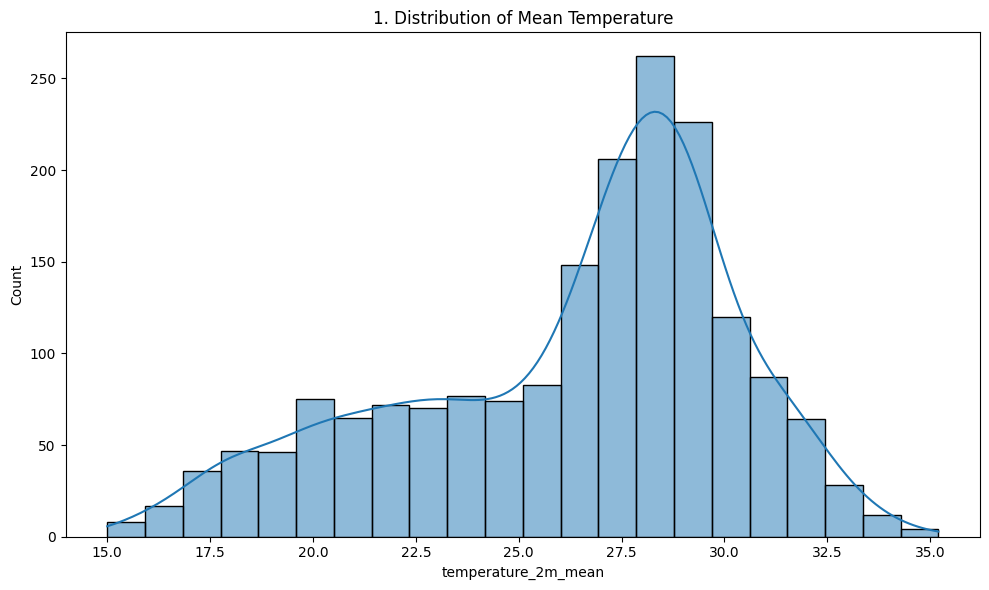

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='temperature_2m_mean', kde=True)
plt.title(f'{plot_no}. Distribution of Mean Temperature')
show_fig()
plot_no += 1

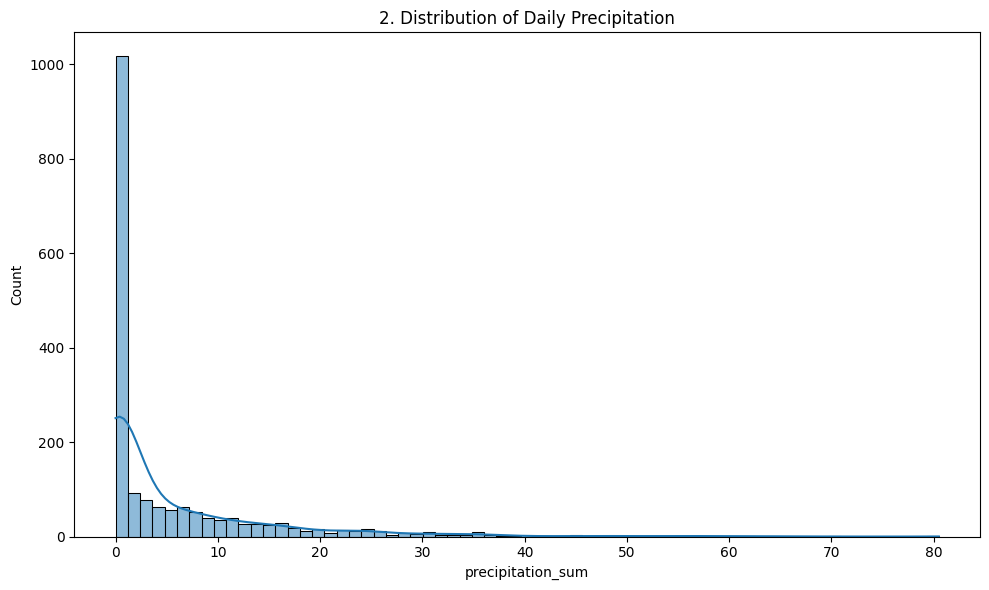

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='precipitation_sum', kde=True)
plt.title(f'{plot_no}. Distribution of Daily Precipitation')
show_fig()
plot_no += 1

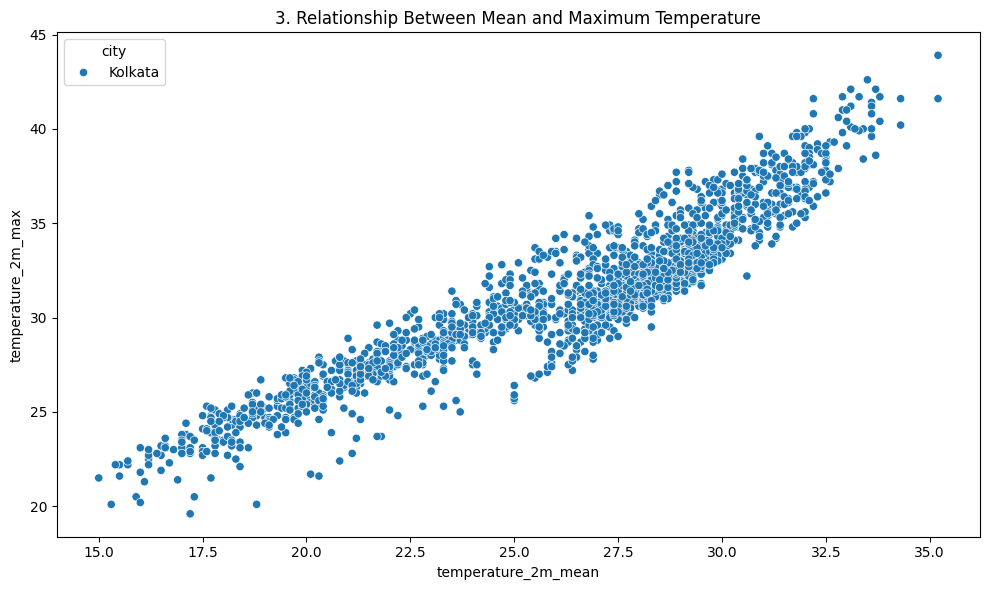

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='temperature_2m_mean', y='temperature_2m_max', hue='city')
plt.title(f'{plot_no}. Relationship Between Mean and Maximum Temperature')
show_fig()
plot_no += 1

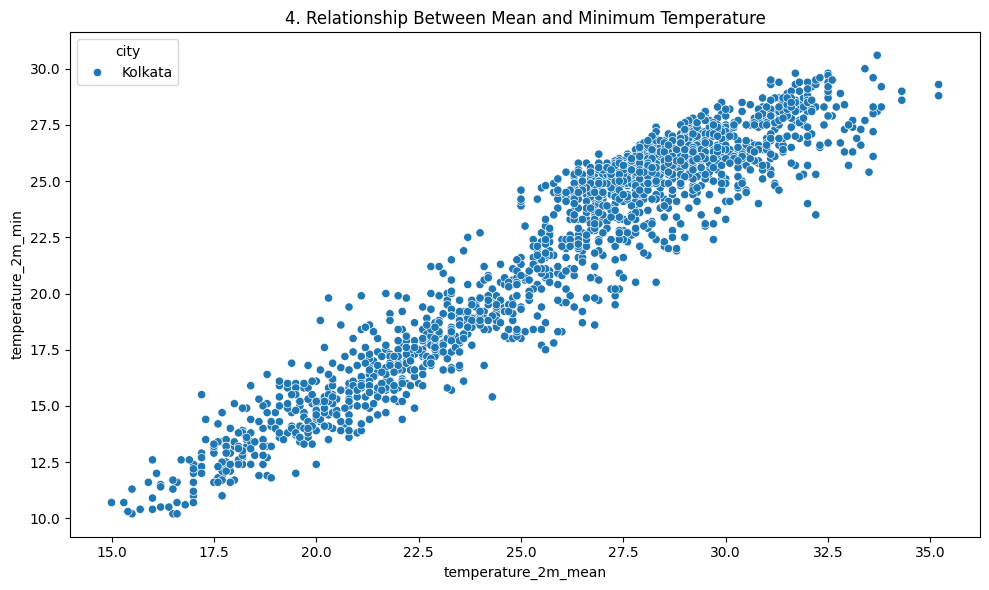

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='temperature_2m_mean', y='temperature_2m_min', hue='city')
plt.title(f'{plot_no}. Relationship Between Mean and Minimum Temperature')
show_fig()
plot_no += 1

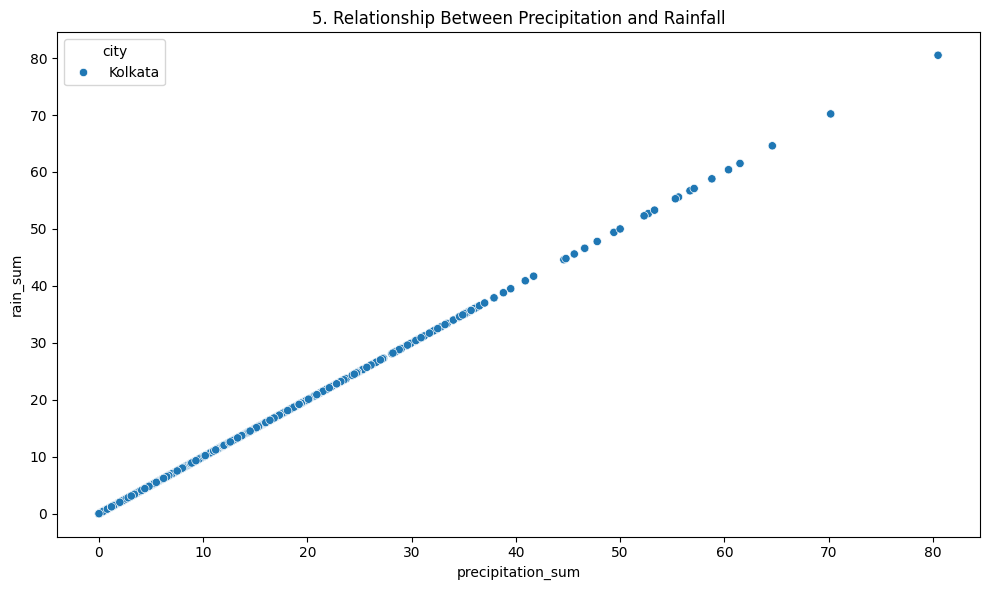

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='precipitation_sum', y='rain_sum', hue='city')
plt.title(f'{plot_no}. Relationship Between Precipitation and Rainfall')
show_fig()
plot_no += 1

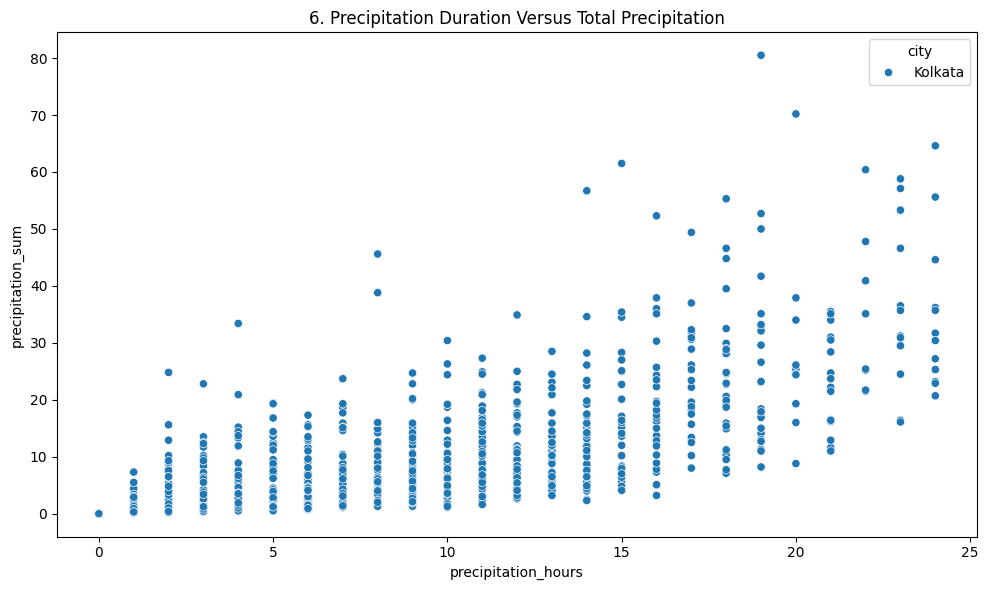

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='precipitation_hours', y='precipitation_sum', hue='city')
plt.title(f'{plot_no}. Precipitation Duration Versus Total Precipitation')
show_fig()
plot_no += 1

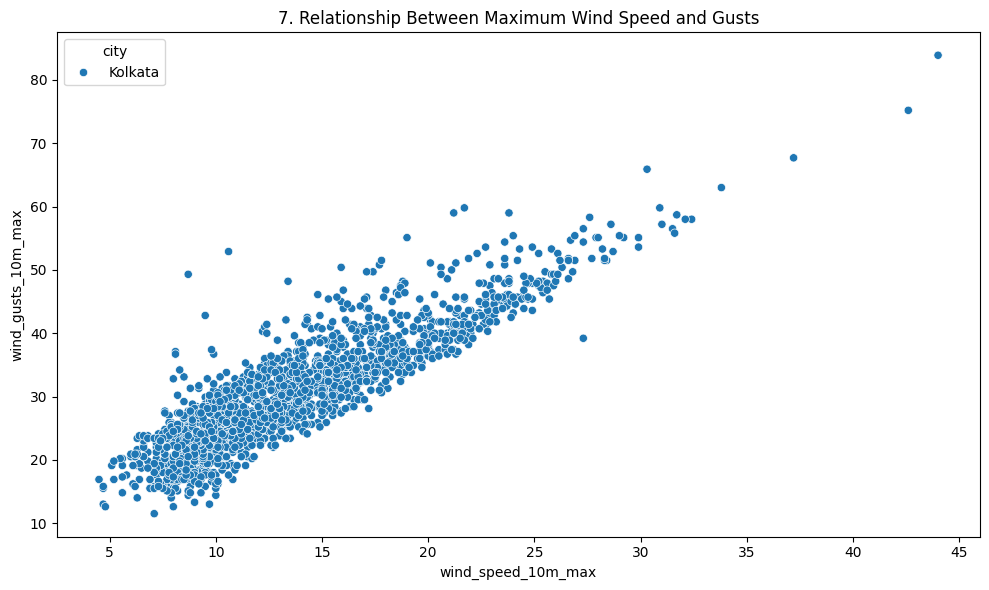

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='wind_speed_10m_max', y='wind_gusts_10m_max', hue='city')
plt.title(f'{plot_no}. Relationship Between Maximum Wind Speed and Gusts')
show_fig()
plot_no += 1

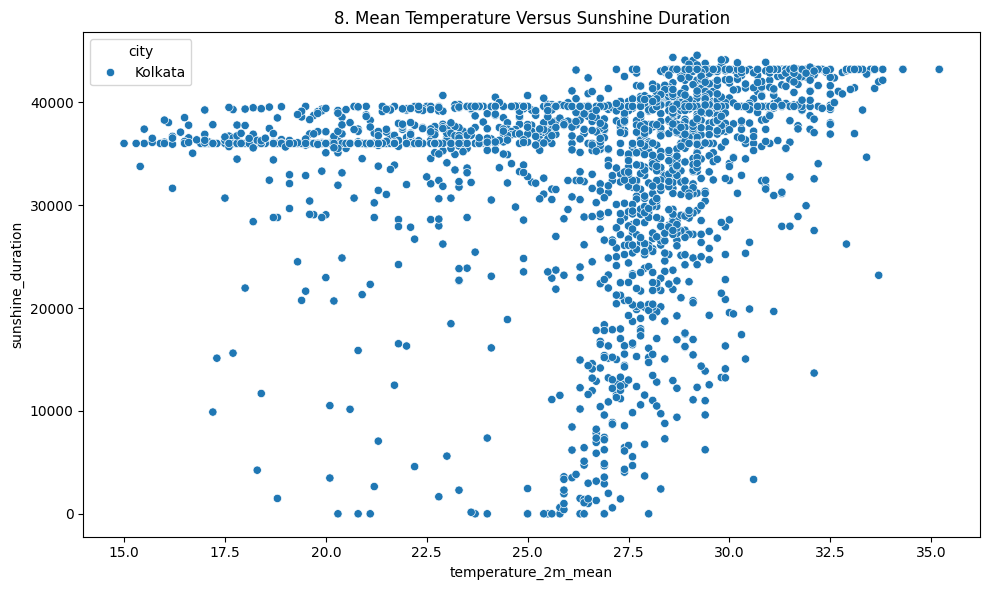

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='temperature_2m_mean', y='sunshine_duration', hue='city')
plt.title(f'{plot_no}. Mean Temperature Versus Sunshine Duration')
show_fig()
plot_no += 1

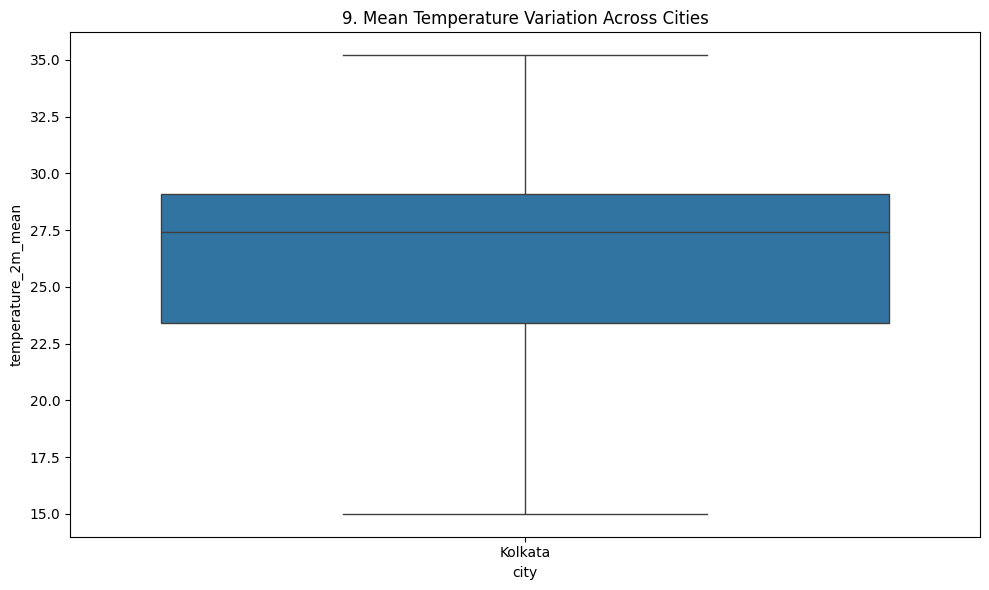

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='city', y='temperature_2m_mean')
plt.title(f'{plot_no}. Mean Temperature Variation Across Cities')
show_fig()
plot_no += 1

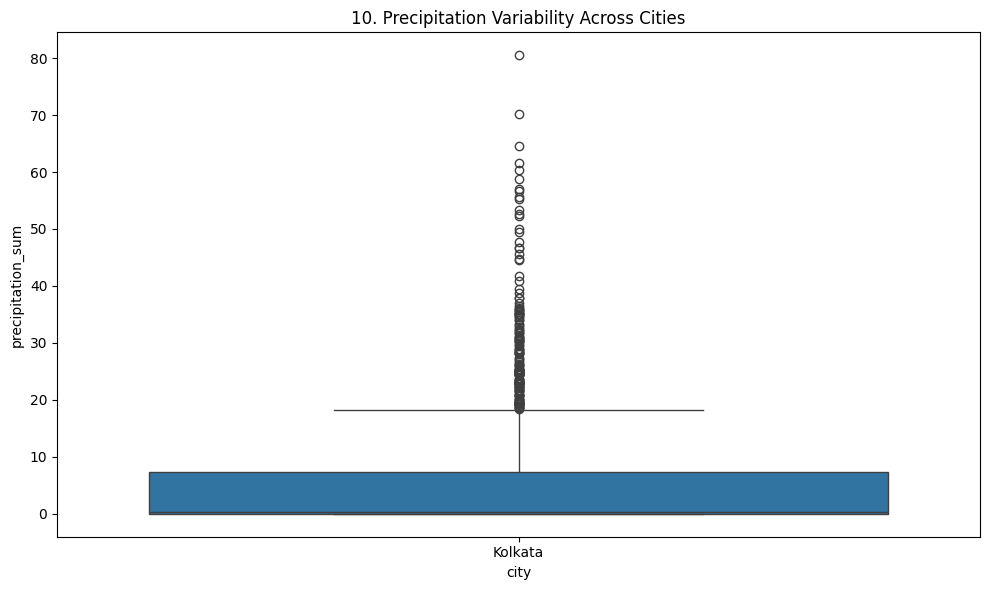

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='city', y='precipitation_sum')
plt.title(f'{plot_no}. Precipitation Variability Across Cities')
show_fig()
plot_no += 1

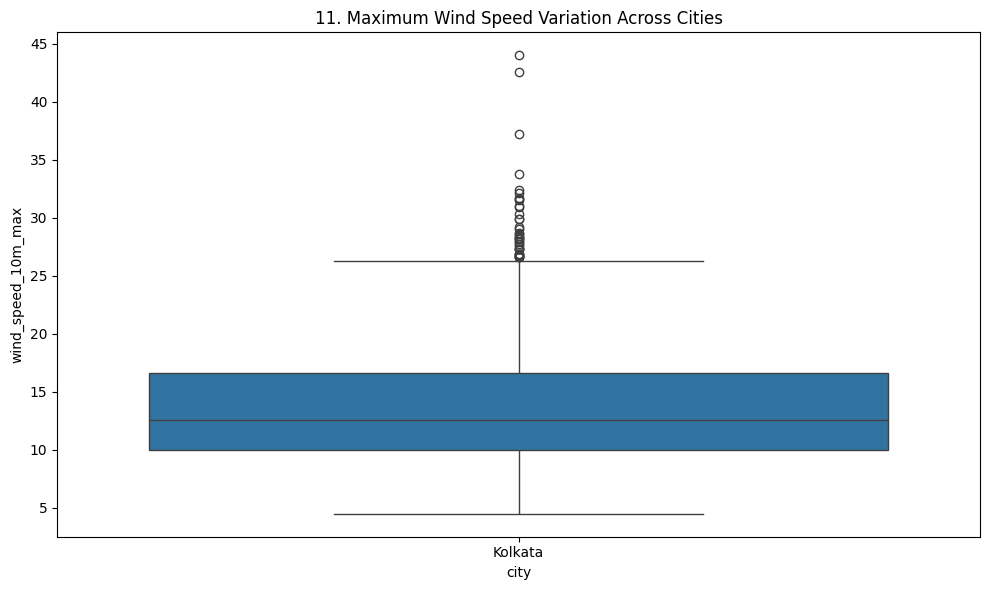

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='city', y='wind_speed_10m_max')
plt.title(f'{plot_no}. Maximum Wind Speed Variation Across Cities')
show_fig()
plot_no += 1

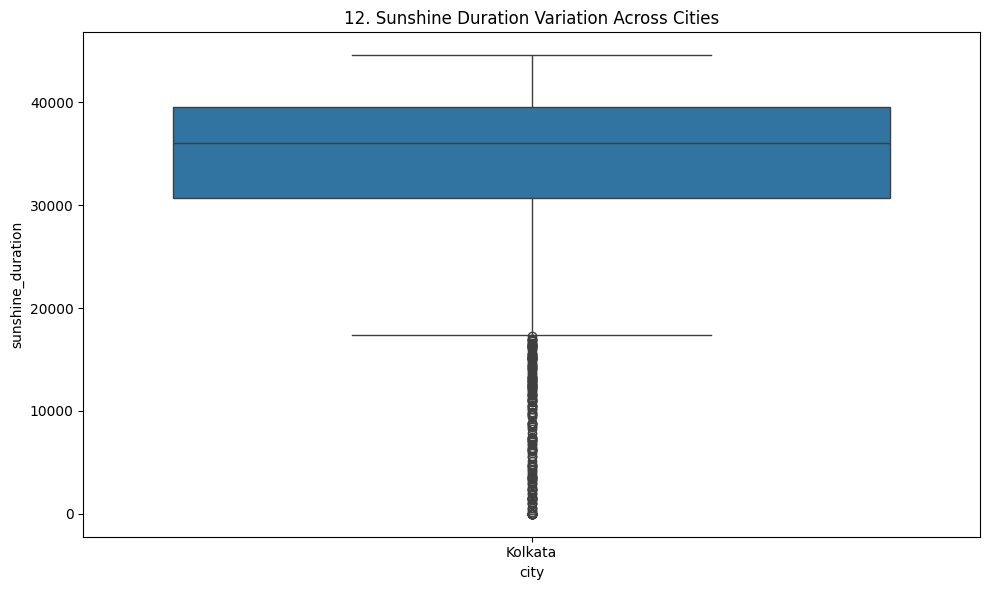

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='city', y='sunshine_duration')
plt.title(f'{plot_no}. Sunshine Duration Variation Across Cities')
show_fig()
plot_no += 1

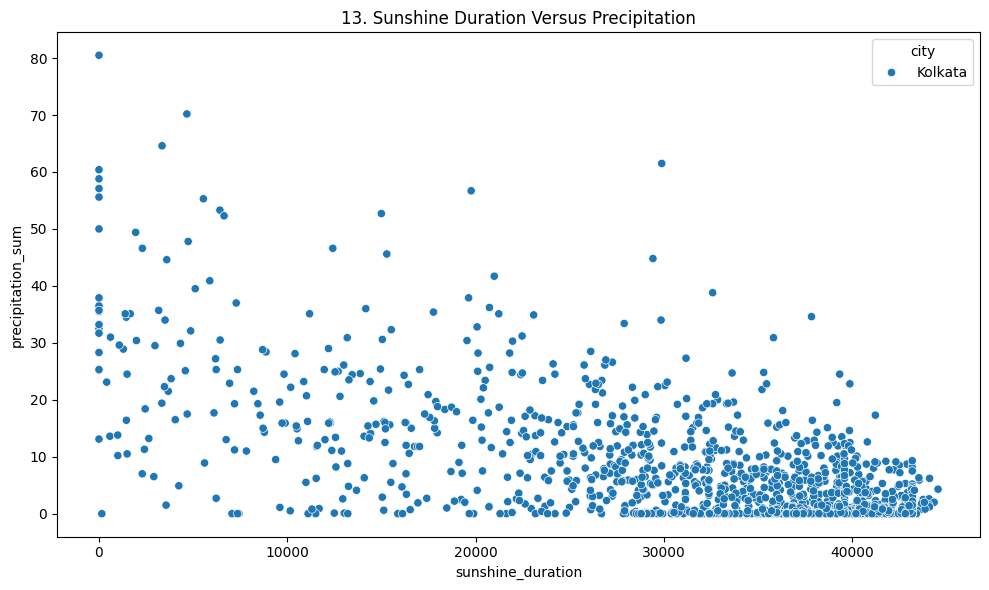

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='sunshine_duration', y='precipitation_sum', hue='city')
plt.title(f'{plot_no}. Sunshine Duration Versus Precipitation')
show_fig()
plot_no += 1

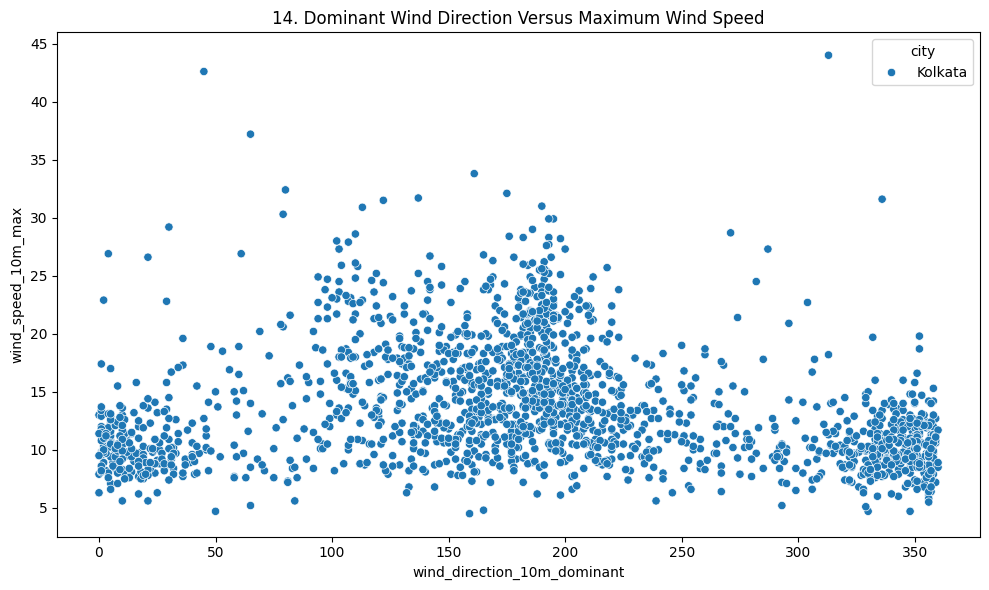

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='wind_direction_10m_dominant', y='wind_speed_10m_max', hue='city')
plt.title(f'{plot_no}. Dominant Wind Direction Versus Maximum Wind Speed')
show_fig()
plot_no += 1

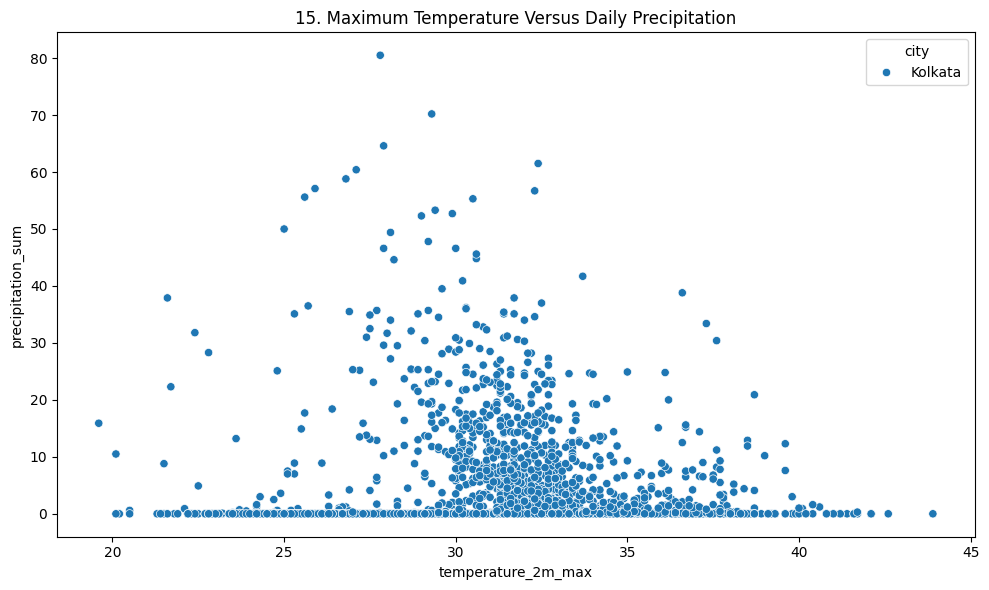

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='temperature_2m_max', y='precipitation_sum', hue='city')
plt.title(f'{plot_no}. Maximum Temperature Versus Daily Precipitation')
show_fig()
plot_no += 1

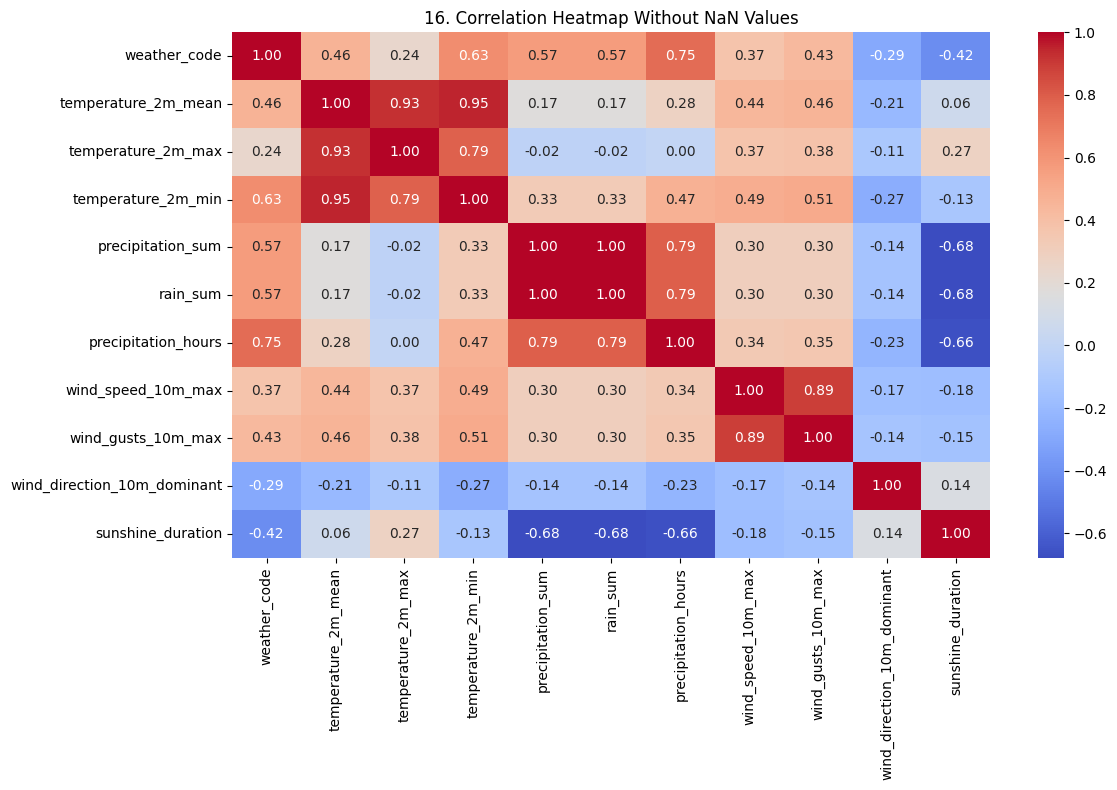

In [28]:
corr = df.select_dtypes(include='number').corr()
corr = corr.dropna(axis=0, how='all').dropna(axis=1, how='all')

fig = plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap Without NaN Values')
show_fig()
plot_no += 1

# Model Training

## Select useful numeric features and target

In [29]:
features = [
    'weather_code',
    'temperature_2m_max',
    'temperature_2m_min',
    'precipitation_sum',
    'rain_sum',
    'precipitation_hours',
    'wind_speed_10m_max',
    'wind_gusts_10m_max',
    'wind_direction_10m_dominant',
    'sunshine_duration'
]
target = 'temperature_2m_mean'

## Prepare the data

In [30]:
model_df = df[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

## Split the dataset

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

## Train the Gradient Boosting model

In [32]:
model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)
model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,300
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,5
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## Make predictions

In [33]:
y_pred = model.predict(X_test)

## Calculate model performance

In [34]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"Accuracy Score: {r2 * 100:.2f}%")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.9909
Accuracy Score: 99.09%
MAE: 0.2952
RMSE: 0.3921


## Plot actual versus predicted values

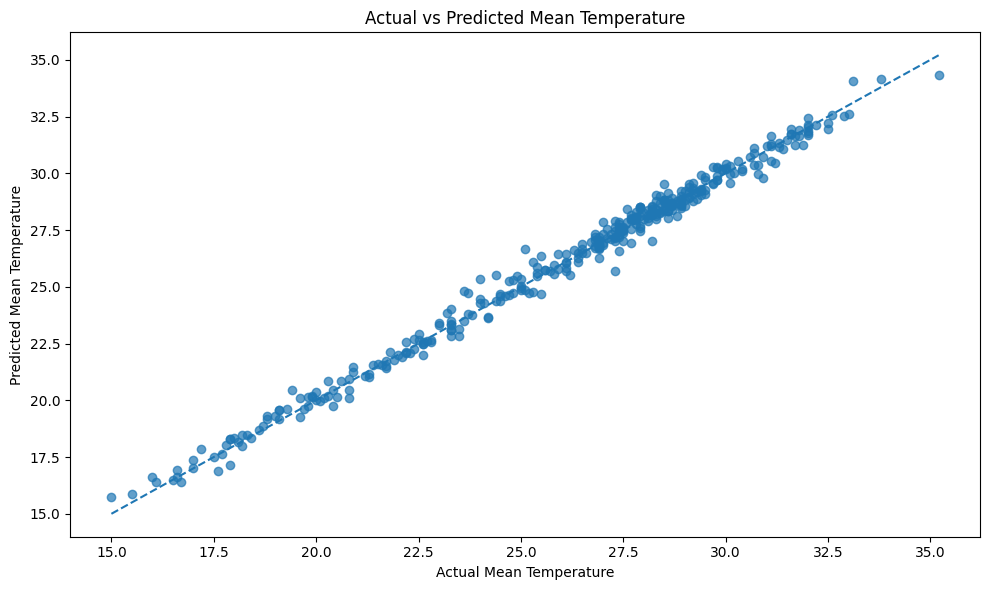

In [35]:
fig = plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)
plt.xlabel('Actual Mean Temperature')
plt.ylabel('Predicted Mean Temperature')
plt.title('Actual vs Predicted Mean Temperature')
show_fig()
plot_no += 1